# Do EELR TDE hosts have consistent and/or brighter IR dust echoes?

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import otter

db = otter.Otter(os.environ['OTTER_DATA_DIR'])

In [3]:
eelr_tdes = ['AT2019azh', 'ASASSN-14li', 'iPTF16fnl']
tdes = db.query(names=eelr_tdes)
hosts = [t.get_host()[0] for t in tdes]
wise_phot = {h.transient_name:h.query_wise() for h in hosts}


KeyboardInterrupt



In [ ]:
fig, axs = plt.subplots(3,1, figsize=(18,24), sharex=True)
for (name, phot), ax in zip(wise_phot.items(), axs):
    
    phot = phot.to_pandas()
    ax.errorbar(phot.mjd, phot.w1mpro, yerr=phot.w1sigmpro, marker='o', linestyle='none', label='W1')
    ax.errorbar(phot.mjd, phot.w2mpro, yerr=phot.w2sigmpro, marker='o', linestyle='none', label='W2')
    
    discovery = db.get_meta(names=name)[0].get_discovery_date()
    ax.axvline(discovery.mjd, linestyle='--', color='r')
    
    ax.invert_yaxis()
    

axs[0].text(57_000, 13.5, list(wise_phot.keys())[0])
axs[1].text(57_000, 13.5, list(wise_phot.keys())[1])
axs[2].text(58_000, 14, list(wise_phot.keys())[2])

    
# ax.legend()

fig.supxlabel('MJD', fontsize=18)
fig.supylabel(r'Apparent Magnitude', fontsize=18)

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:601: UserWarning: Unable to apply the source mapping because '2021MNRAS.500.1673H,2022ApJ...925...67L,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))


Text(0.02, 0.5, 'Apparent Magnitude')

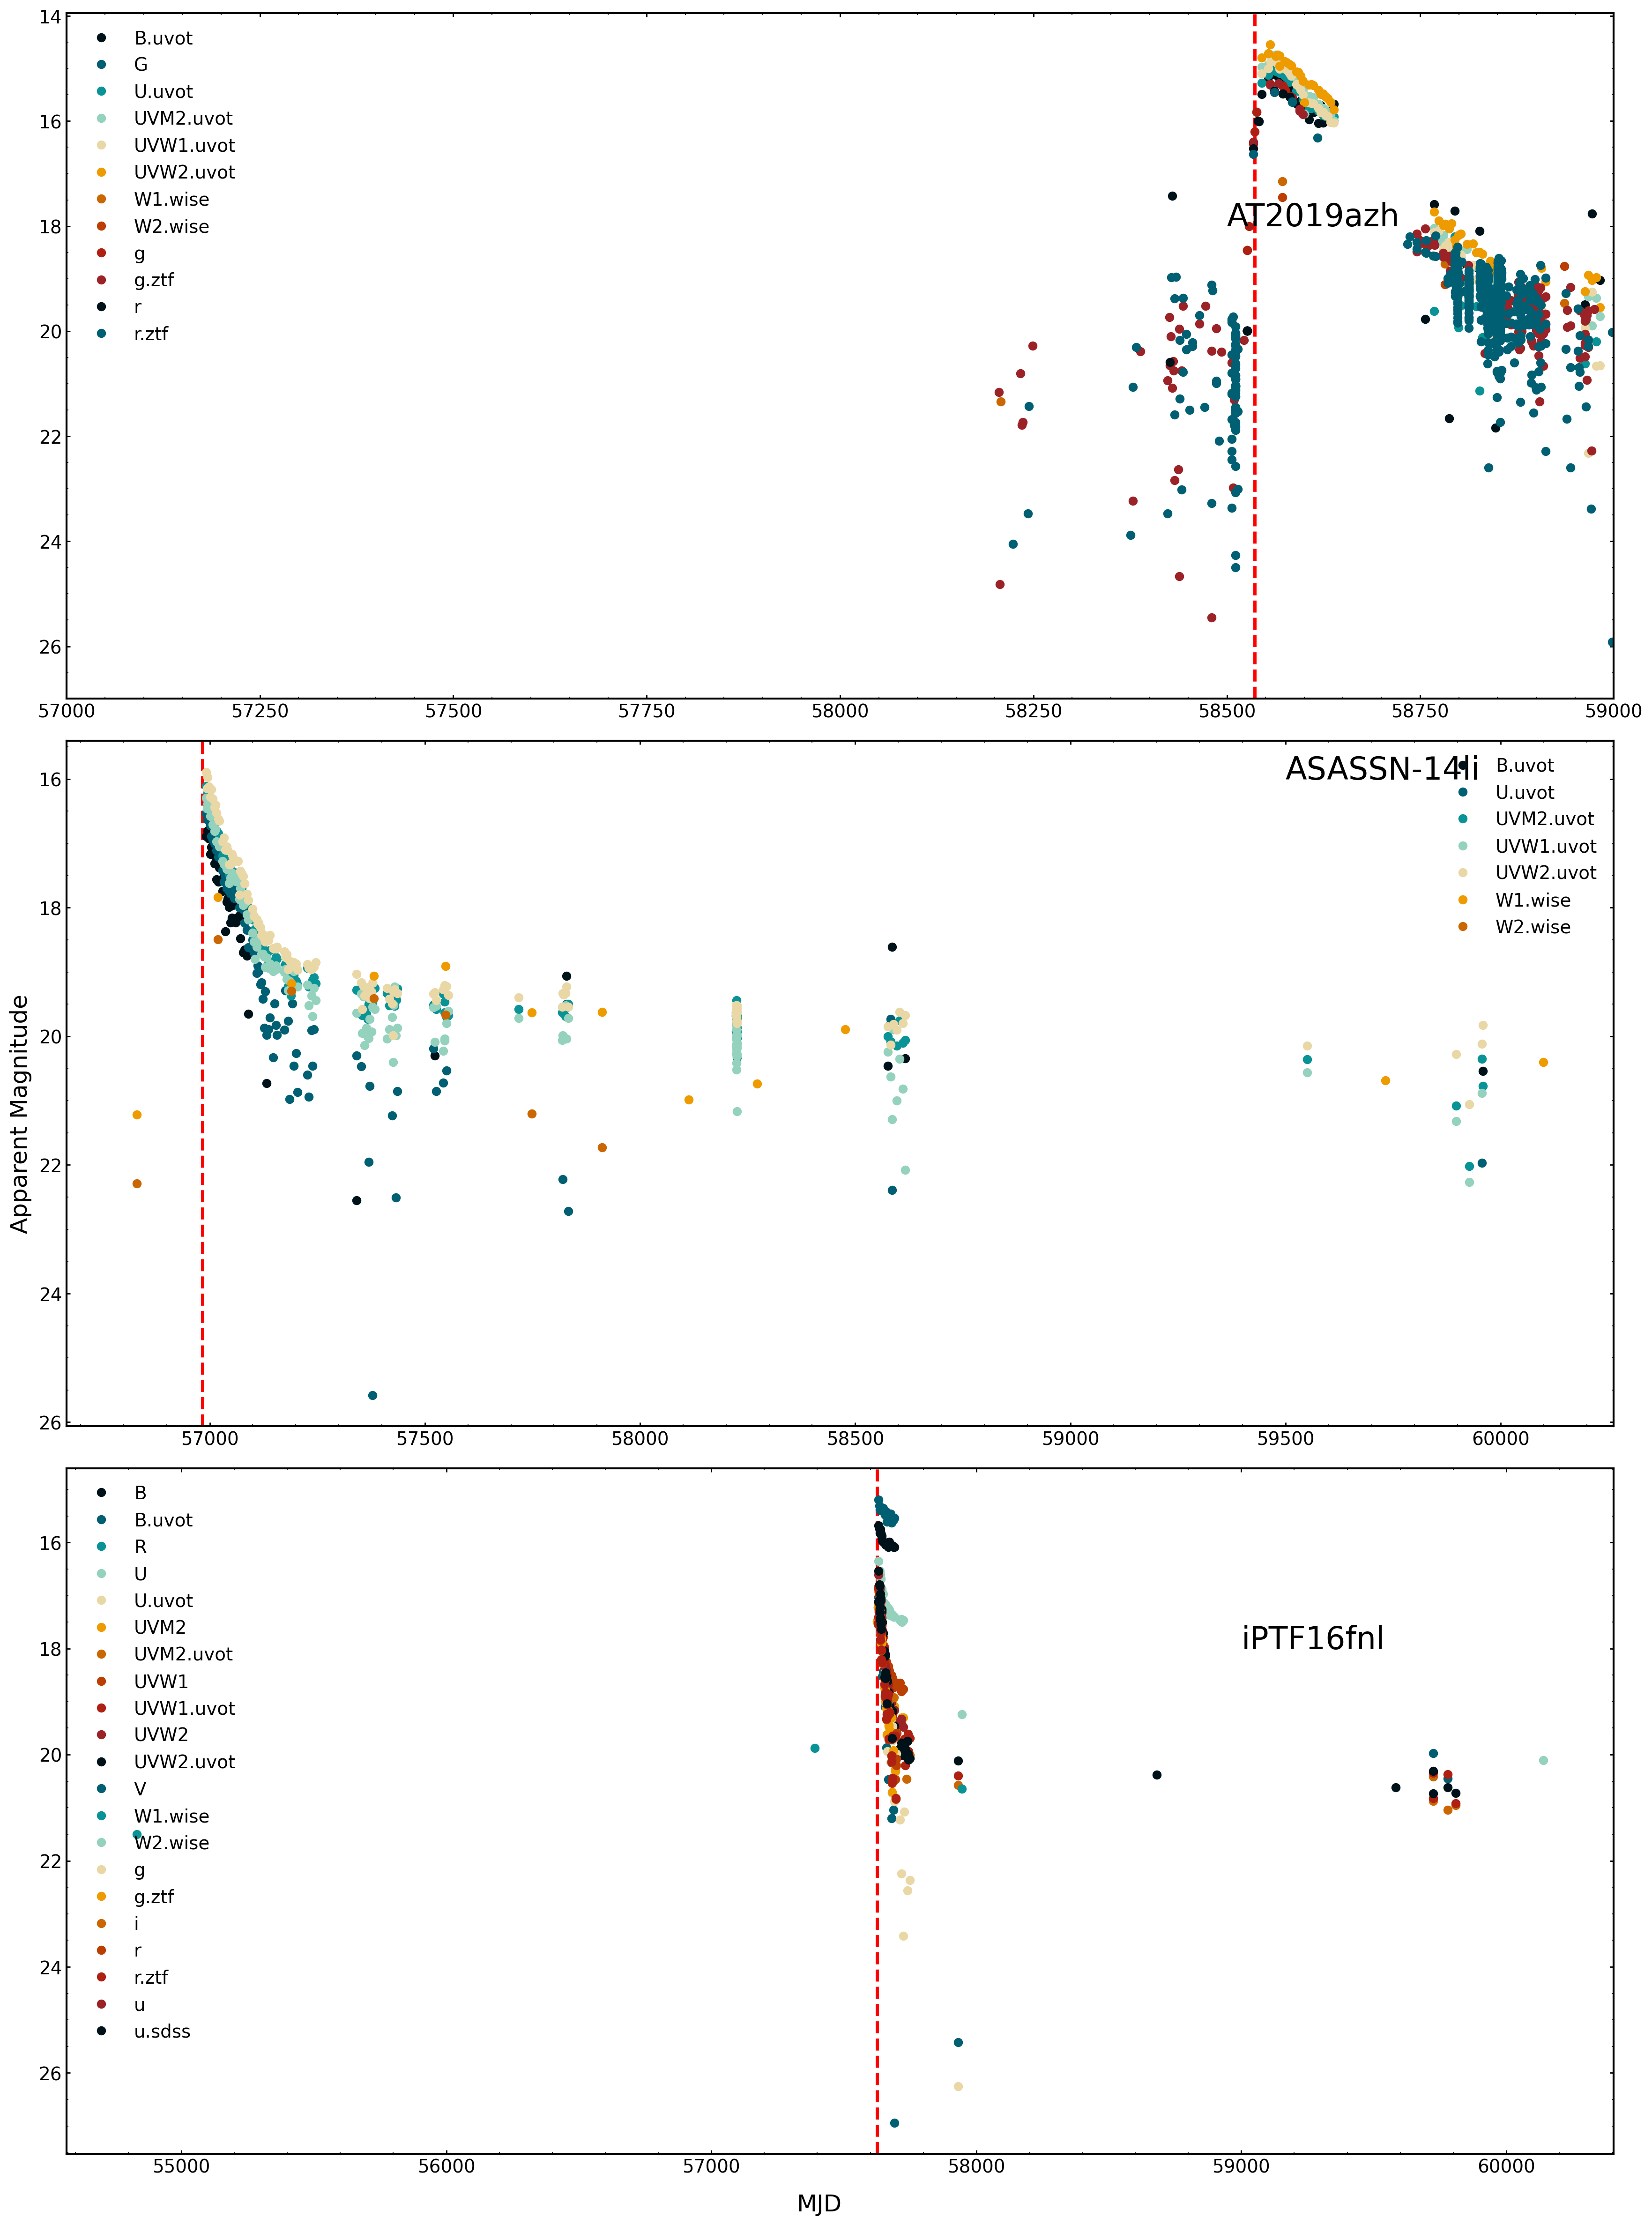

In [7]:
fig, axs = plt.subplots(3,1, figsize=(18,24), sharex=False)
names = eelr_tdes
for name, ax in zip(names, axs):
    
    all_phot = db.get_phot(names=name, obs_type='uvoir', return_type='pandas')
    for band, phot in all_phot.groupby('filter_name'):
        #if 'wise' not in band: continue
        ax.errorbar(phot.converted_date, phot.converted_flux, marker='o', linestyle='none', label=band, uplims=phot.upperlimit)
    
    discovery = db.get_meta(names=name)[0].get_discovery_date()
    ax.axvline(discovery.mjd, linestyle='--', color='r')
    
    ax.invert_yaxis()
    
    ax.legend()

axs[0].text(58_500, 18, names[0], fontsize=24)
axs[1].text(59_500, 16, names[1], fontsize=24)
axs[2].text(59_000, 18, names[2], fontsize=24)

axs[0].set_xlim(57_000, 59_000)

# ax.legend()

fig.supxlabel('MJD', fontsize=18)
fig.supylabel(r'Apparent Magnitude', fontsize=18)

Text(0.02, 0.5, 'Apparent Magnitude')

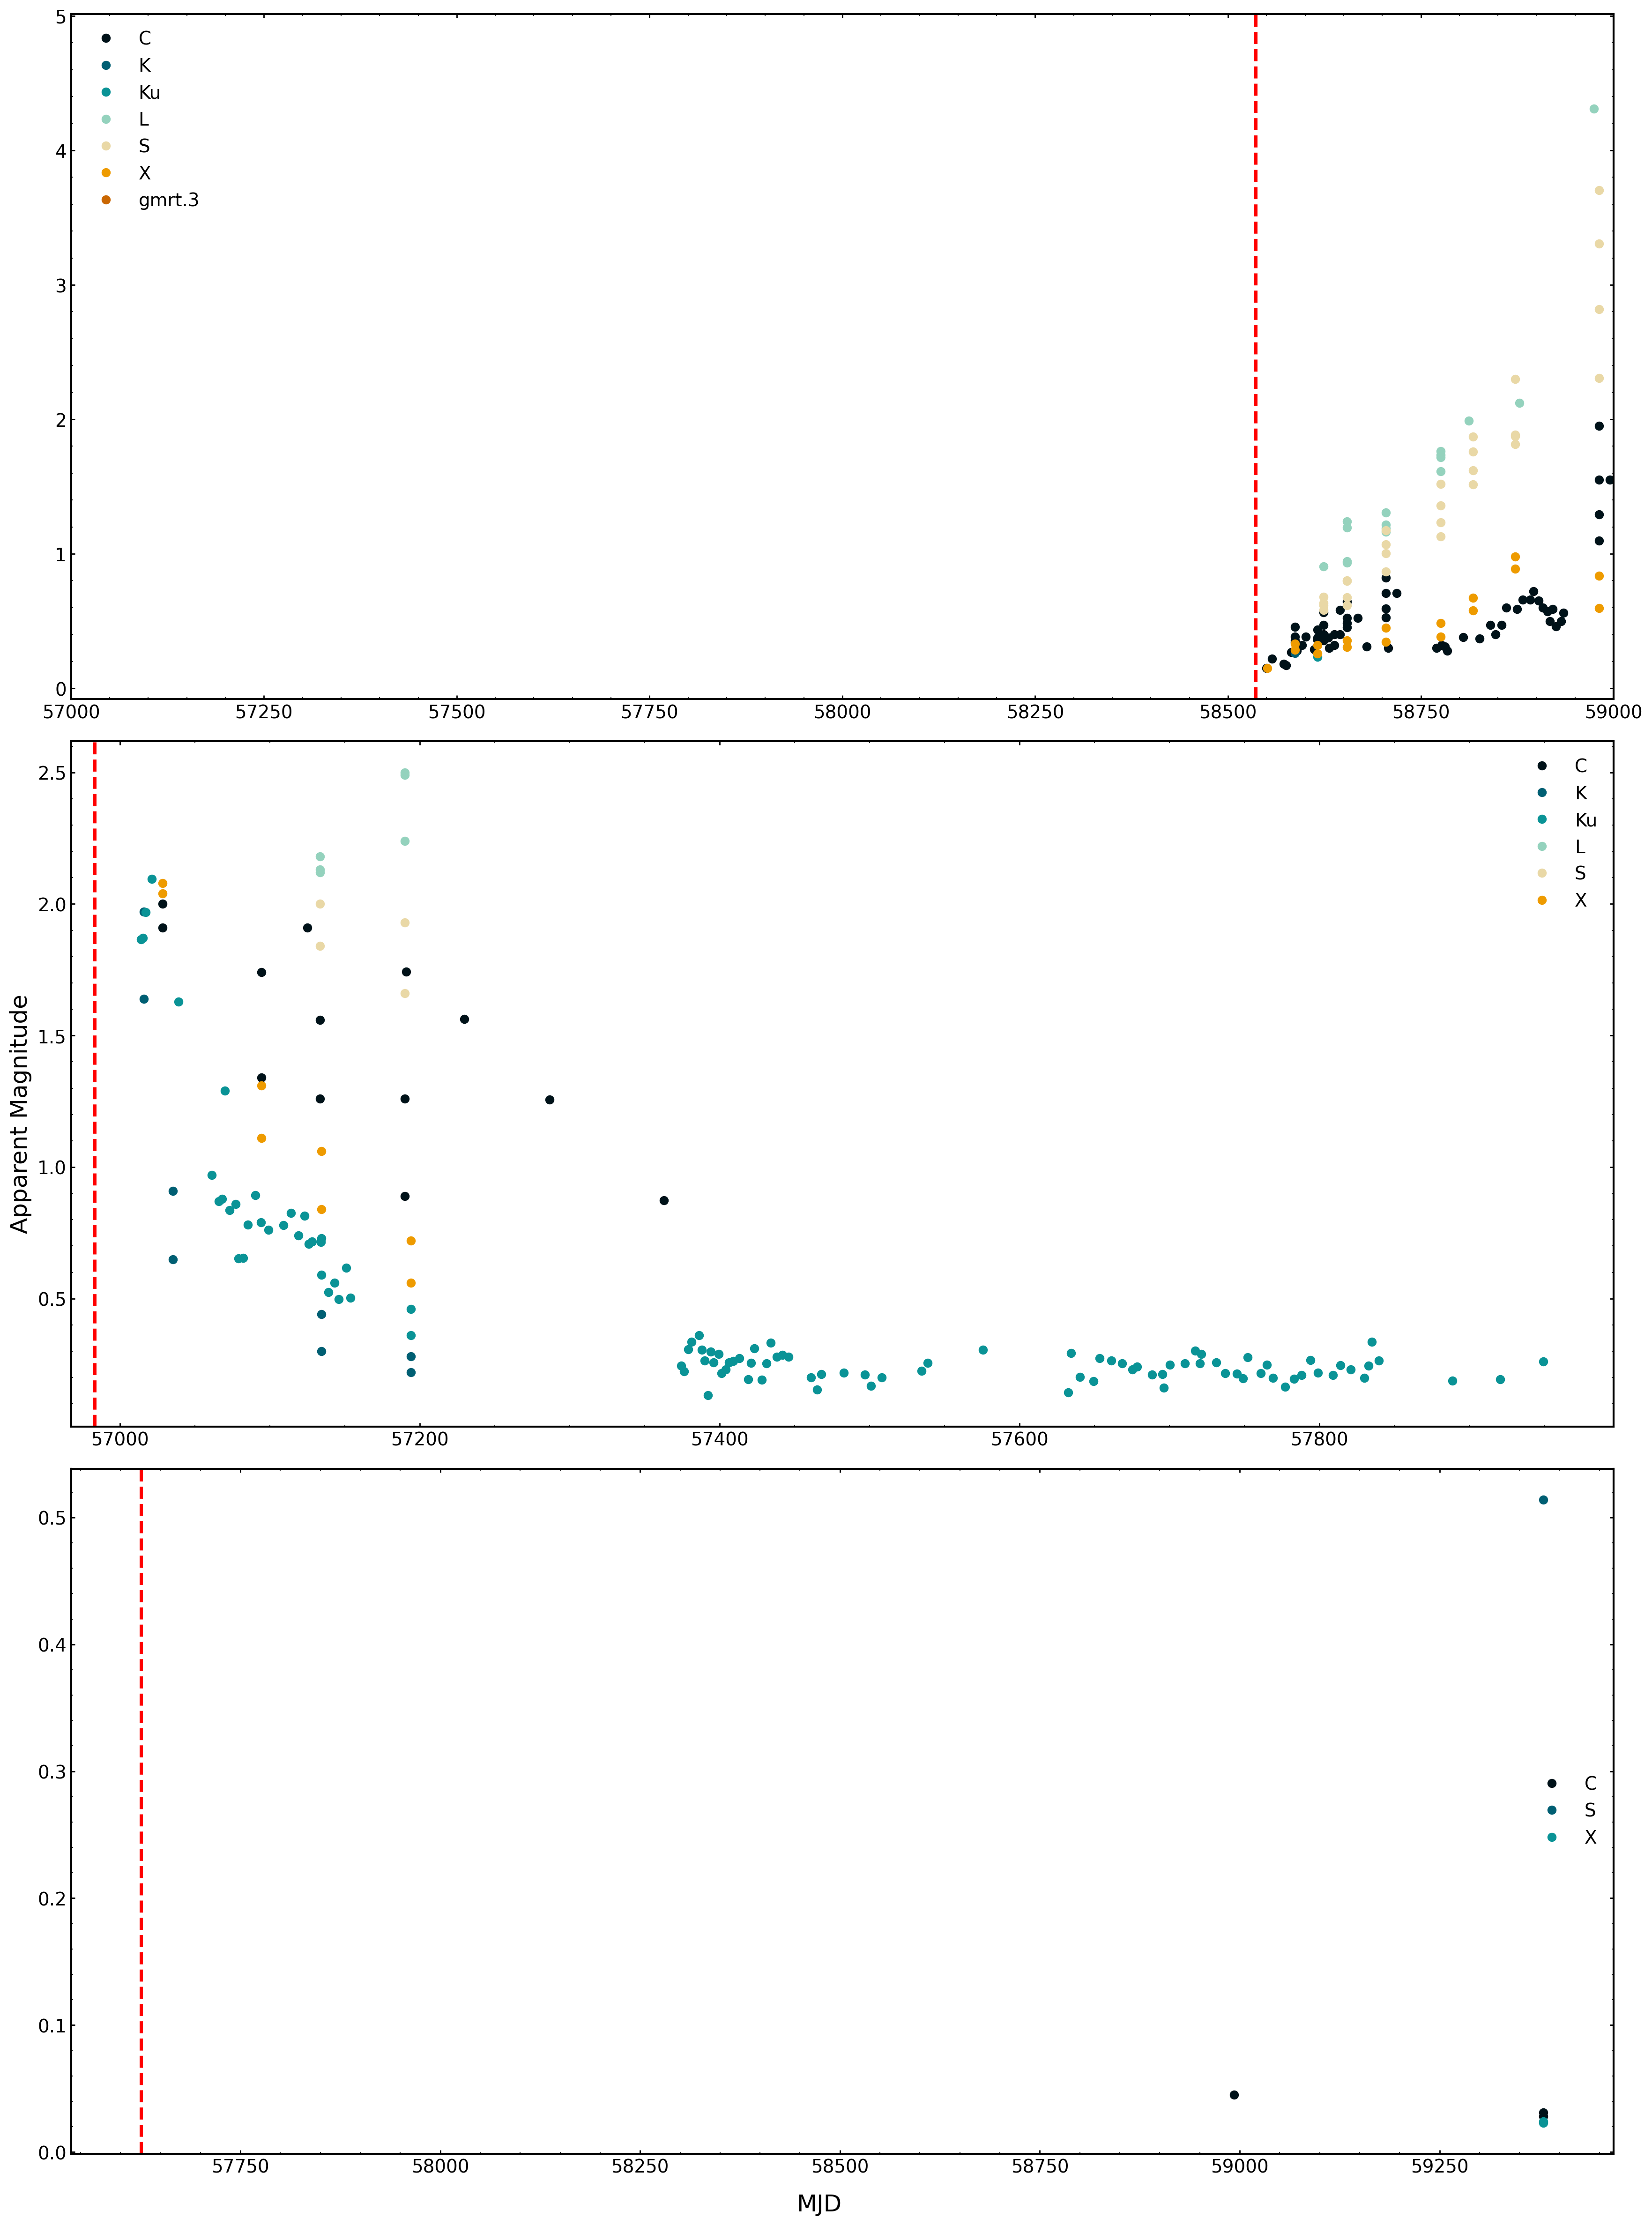

In [11]:
fig, axs = plt.subplots(3,1, figsize=(18,24), sharex=False)
names = eelr_tdes
for name, ax in zip(names, axs):
    
    all_phot = db.get_phot(names=name, obs_type='radio', return_type='pandas', flux_unit='mJy')
    for band, phot in all_phot.groupby('filter_name'):
        #if 'wise' not in band: continue
        ax.errorbar(phot.converted_date, phot.converted_flux, marker='o', linestyle='none', label=band, uplims=phot.upperlimit)
    
    discovery = db.get_meta(names=name)[0].get_discovery_date()
    ax.axvline(discovery.mjd, linestyle='--', color='r')
    
    # ax.invert_yaxis()
    
    ax.legend()

# axs[0].text(58_500, 18, names[0], fontsize=24)
# axs[1].text(59_500, 16, names[1], fontsize=24)
# axs[2].text(59_000, 18, names[2], fontsize=24)

axs[0].set_xlim(57_000, 59_000)

# ax.legend()

fig.supxlabel('MJD', fontsize=18)
fig.supylabel(r'Apparent Magnitude', fontsize=18)


In [ ]:
PSB